In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("clean_movies.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  500 non-null    int64
 1   title     500 non-null    str  
 2   genres    500 non-null    str  
 3   overview  500 non-null    str  
dtypes: int64(1), str(3)
memory usage: 62.2 KB


In [4]:
df.describe(include="all")

,movie_id,title,genres,overview
count,500.000000,500,500,500
unique,NaN,500,10,6
top,NaN,Shadow Journey,Drama,An unexpected discovery changes the lives of e...
freq,NaN,1,70,94
mean,250.500000,NaN,NaN,NaN
std,144.481833,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,125.750000,NaN,NaN,NaN
50%,250.500000,NaN,NaN,NaN
75%,375.250000,NaN,NaN,NaN


In [5]:
genre_counts = (
    df["genres"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

genre_counts

genres
Drama                70
Action|Adventure     55
Crime|Thriller       55
Comedy               53
Sci-Fi|Adventure     51
Fantasy|Adventure    47
Action|Sci-Fi        44
Romance|Drama        43
Horror|Mystery       43
Animation|Family     39
Name: count, dtype: int64

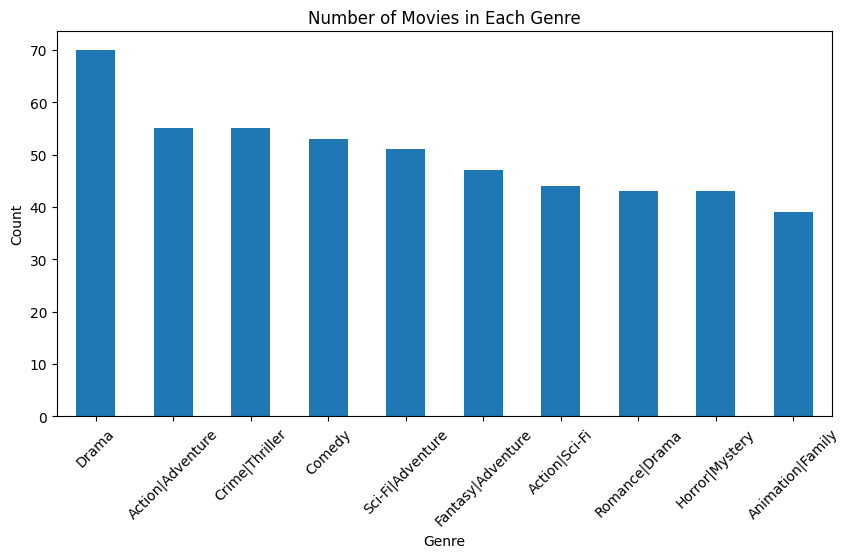

In [6]:
plt.figure(figsize=(10,5))

genre_counts.plot(kind="bar")

plt.title("Number of Movies in Each Genre")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [7]:
df["overview_length"] = df["overview"].apply(lambda x: len(x.split()))

In [8]:
df[["title","overview_length"]].head()

,title,overview_length
0,Shadow Journey,12
1,Shadow Empire,9
2,Shadow Legacy,12
3,Shadow Promise,12
4,Shadow Storm,12


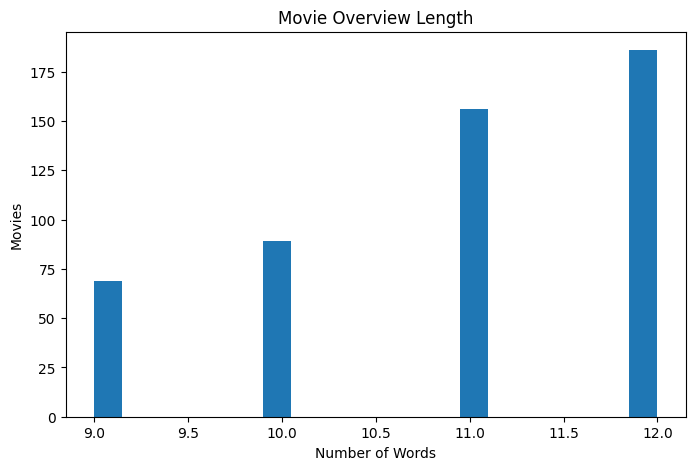

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["overview_length"], bins=20)

plt.title("Movie Overview Length")
plt.xlabel("Number of Words")
plt.ylabel("Movies")

plt.show()

In [10]:
df.sort_values(by="overview_length", ascending=False)[["title","overview_length"]].head(10)

,title,overview_length
0,Shadow Journey,12
251,Iron Code,12
272,Mystic Hunter,12
268,Mystic Dream,12
262,Mystic Legacy,12
260,Mystic Journey,12
255,Iron River,12
254,Iron Night,12
248,Iron Dream,12
319,Royal Guardian,12


In [11]:
df.sort_values(by="overview_length")[["title","overview_length"]].head(10)

,title,overview_length
375,Burning River,9
446,Wild Horizon,9
223,Emerald Promise,9
449,Wild Chronicle,9
102,Last Legacy,9
199,Frozen Guardian,9
187,Frozen Quest,9
415,Silver River,9
48,Silent Dream,9
46,Silent Horizon,9


In [12]:
df["title"].head(10)

0      Shadow Journey
1       Shadow Empire
2       Shadow Legacy
3      Shadow Promise
4        Shadow Storm
5         Shadow Echo
6      Shadow Horizon
7        Shadow Quest
8        Shadow Dream
9    Shadow Chronicle
Name: title, dtype: str

In [13]:
df.to_csv("final_movies.csv", index=False)